# 📊 Give Me Some Credit — Análisis de Riesgo Crediticio

**Competencia de Kaggle:** [Give Me Some Credit](https://www.kaggle.com/competitions/give-me-some-credit/data)

### Objetivo del Proyecto
Construir un modelo de *scoring* crediticio que prediga la probabilidad de que un prestatario presente un **incumplimiento grave** (morosidad de 90 días o más) en los próximos dos años.  
La variable objetivo es `SeriousDlqin2yrs` (1 = incumplimiento, 0 = cumplimiento).

### Enfoque Metodológico
1. **Carga y exploración** de los datos (EDA).
2. **Limpieza y transformación** de variables (tratamiento de nulos, outliers y distribuciones sesgadas).
3. **Modelado predictivo** con XGBoost, incluyendo optimización de hiperparámetros con Optuna.
4. **Evaluación comparativa** de estrategias de balanceo (pesos algorítmicos vs. SMOTE).
5. **Interpretabilidad** del modelo con SHAP.

### Stack Tecnológico
| Librería | Uso |
|----------|-----|
| `pandas` / `numpy` | Manipulación de datos |
| `matplotlib` / `seaborn` | Visualización |
| `scikit-learn` | Preprocesamiento, métricas e imputación (MICE) |
| `xgboost` | Modelo de clasificación |
| `optuna` | Optimización bayesiana de hiperparámetros |
| `shap` | Explicabilidad del modelo |
| `imbalanced-learn` | Balanceo con SMOTE |

---

## 1. Importación de Librerías
Cargamos las librerías base necesarias para el análisis exploratorio y la visualización de datos.

In [1]:
# Librerías fundamentales para análisis de datos y visualización
import pandas as pd       # Manipulación de DataFrames
import numpy as np        # Operaciones numéricas y álgebra lineal
import matplotlib.pyplot as plt  # Visualización de gráficos
import seaborn as sns     # Visualización estadística avanzada

## 2. Descarga y Carga de Datos
Los datos pueden descargarse directamente desde la API de Kaggle o de forma manual.  
Puedes usar el bloque de código comentado si configuras tu entorno con `kagglehub`.  
En cualquier caso, los datos están disponibles en: [Data — Give Me Some Credit](https://www.kaggle.com/competitions/give-me-some-credit/data)

In [42]:
# === Opción 1: Descarga automática desde Kaggle (requiere configuración previa) ===
# Para usar este bloque, necesitas:
#   1. Instalar kagglehub: pip install kagglehub
#   2. Configurar tu API key de Kaggle en ~/.kaggle/kaggle.json
"""
import kagglehub

# Descargar la versión más reciente del dataset
path = kagglehub.competition_download('give-me-some-credit')

print("Path to competition files:", path)
"""

'\nimport kagglehub\n\n# Download latest version\npath = kagglehub.competition_download(\'give-me-some-credit\')\n\nprint("Path to competition files:", path)\n'

In [43]:
# === Opción 2: Carga desde Google Drive (si trabajas en Google Colab) ===
"""
from google.colab import drive
drive.mount('/content/drive')
path_train= "/content/drive/MyDrive/data/train.csv"
path_test = "/content/drive/MyDrive/data/test.csv"
"""

'\nfrom google.colab import drive\ndrive.mount(\'/content/drive\')\npath_train= "/content/drive/MyDrive/data/train.csv"\npath_test = "/content/drive/MyDrive/data/test.csv"\n'

In [2]:
# === Opción 3: Carga desde archivos locales ===
# Los archivos CSV deben estar en la carpeta 'data/' del proyecto
path_train = "data/train.csv"
path_test = "data/test.csv"

In [3]:
# Lectura de los datasets de entrenamiento y prueba
df_train = pd.read_csv(path_train)
df_test = pd.read_csv(path_test)

C:\Users\Diego Roman\AppData\Local\Temp\ipykernel_20960\352102316.py:1: DtypeWarning: Columns (0: Id, 1: SeriousDlqin2yrs, 2: RevolvingUtilizationOfUnsecuredLines, 3: age, 4: NumberOfTime30-59DaysPastDueNotWorse, 5: DebtRatio, 6: MonthlyIncome, 7: NumberOfOpenCreditLinesAndLoans, 8: NumberOfTimes90DaysLate, 9: NumberRealEstateLoansOrLines, 10: NumberOfTime60-89DaysPastDueNotWorse, 11: NumberOfDependents) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train= pd.read_csv(path_train)


## 3. Análisis Exploratorio de Datos (EDA)
En esta sección inspeccionaremos la estructura del dataset, identificaremos valores nulos, analizaremos las distribuciones estadísticas y detectaremos outliers.  
El objetivo es obtener una comprensión profunda de los datos antes de aplicar cualquier transformación.

## Data Dictionary - English


|Variable Name|Description|Type|
|--------------|-----------|------|
|**SeriousDlqin2yrs(target)**|**Person experienced 90 days past due delinquency or worse** |**Y/N**|
|RevolvingUtilizationOfUnsecuredLines|Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits|percentage|
|age|Age of borrower in years|integer|
|NumberOfTime30-59DaysPastDueNotWorse|Number of times borrower has been 30-59 days past due but no worse in the last 2 years|integer|
|DebtRatio|"Monthly debt payments alimony,living costs divided by monthy gross income"|percentage|
|MonthlyIncome|Monthly income,real NumberOfOpenCreditLinesAndLoans,Number of Open loans (installment like car loan or mortgage) and Lines of credit (e.g. credit cards)|integer|
|NumberOfTimes90DaysLate|Number of times borrower has been 90 days or more past due|integer|
|NumberRealEstateLoansOrLines|Number of mortgage and real estate loans including home equity lines of credit|integer|
|NumberOfTime60-89DaysPastDueNotWorse|Number of times borrower has been 60-89 days past due but no worse in the last 2 years|integer|
|NumberOfDependents|"Number of dependents in family excluding themselves (spouse, children etc.)"|integer|

### Diccionario de Datos - Español

|Variable Name|Descripción|Tipo|
|--------------|-----------|------|
|SeriousDlqin2yrs|Persona que ha experimentado mora de 90 días o peor|Y/N|
|RevolvingUtilizationOfUnsecuredLines|Saldo total en tarjetas de crédito y líneas de crédito personales, excluyendo bienes raíces y deudas a plazos como préstamos de automóviles, dividido por la suma de los límites de crédito|porcentaje|
|age|Edad del prestatario en años|entero|
|NumberOfTime30-59DaysPastDueNotWorse|Número de veces que el prestatario ha tenido mora de 30-59 días pero no peor en los últimos 2 años|entero|
|DebtRatio|Pagos mensuales de deuda, pensión alimenticia y costos de vida divididos por el ingreso bruto mensual|porcentaje|
|MonthlyIncome|Ingreso mensual|real|
|NumberOfOpenCreditLinesAndLoans|Número de préstamos abiertos (a plazos como préstamo de automóvil o hipoteca) y líneas de crédito (por ejemplo, tarjetas de crédito)|entero|
|NumberOfTimes90DaysLate|Número de veces que el prestatario ha tenido mora de 90 días o más|entero|
|NumberRealEstateLoansOrLines|Número de préstamos hipotecarios y de bienes raíces, incluidas las líneas de crédito con garantía hipotecaria|entero|
|NumberOfTime60-89DaysPastDueNotWorse|Número de veces que el prestatario ha tenido mora de 60-89 días pero no peor en los últimos 2 años|entero|
|NumberOfDependents|Número de dependientes en la familia, excluyéndose a sí mismo (cónyuge, hijos, etc.)|entero|





In [21]:
df_train.head(10)

,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1
1,2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0
2,3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0
3,4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0
4,5,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1
5,6,0,0.305682,57,0,5710.000000,NaN,8,0,3,0,0
6,7,0,0.754464,39,0,0.209940,3500.0,8,0,0,0,0
7,8,0,0.116951,27,0,46.000000,NaN,2,0,0,0,<NA>
8,10,0,0.644226,30,0,0.309476,2500.0,5,0,0,0,0
9,11,0,0.018798,51,0,0.531529,6501.0,7,0,2,0,2


In [22]:
df_train.tail(10)

,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
104796,149983,0,0.002485,82,0,0.000800,5000.0,5,0,0,0,0
104797,149986,0,0.168102,49,0,0.080384,5000.0,16,0,0,0,1
104798,149987,0,1.000000,28,0,0.055692,3249.0,3,1,0,0,0
104799,149988,0,0.902051,31,1,0.347924,7515.0,10,0,1,0,0
104800,149990,0,0.055518,46,0,0.609779,4335.0,7,0,1,0,2
104801,149991,0,0.104112,59,0,0.477658,10316.0,10,0,2,0,0
104802,149993,0,1.000000,22,0,0.000000,820.0,1,0,0,0,0
104803,149998,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0
104804,149999,0,0.850283,64,0,0.249908,8158.0,8,0,2,0,0
104805,<NA>,<NA>,NaN,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>


> ⚠️ **Observación:** La última fila del DataFrame contiene el encabezado duplicado como datos. Esto indica un problema en el archivo CSV original que debe corregirse antes de continuar.

In [23]:
# Eliminación de la última fila (encabezado duplicado detectado en el EDA)
# Nota: drop() sin inplace=True retorna una copia. Se usa para visualizar el resultado.
df_train.drop(df_train.index[-1])

,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1
1,2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0
2,3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0
3,4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0
4,5,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
104800,149990,0,0.055518,46,0,0.609779,4335.0,7,0,1,0,2
104801,149991,0,0.104112,59,0,0.477658,10316.0,10,0,2,0,0
104802,149993,0,1.000000,22,0,0.000000,820.0,1,0,0,0,0
104803,149998,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0


In [24]:
df_test.head(10)

,Id,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,9,0.189169,57,0,0.606291,23684.0,9,0,4,0,2.0
2,17,0.166284,53,0,0.188274,8800.0,7,0,0,0,0.0
3,18,0.221813,43,0,0.527888,3280.0,7,0,1,0,2.0
4,24,0.046560,58,0,0.241622,2416.0,9,0,1,0,0.0
5,26,0.052436,58,0,0.097672,8333.0,22,0,1,0,0.0
6,31,1.000000,24,0,0.472703,750.0,1,0,0,0,0.0
7,34,0.693330,42,2,0.257732,2230.0,7,0,0,0,0.0
8,35,0.000000,64,0,0.073539,11000.0,9,0,1,0,0.0
9,37,1.000000,75,1,0.134078,3400.0,1,0,1,0,1.0


In [25]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 104806 entries, 0 to 104805
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Id                                    104805 non-null  Int64  
 1   SeriousDlqin2yrs                      104805 non-null  Int8   
 2   RevolvingUtilizationOfUnsecuredLines  104805 non-null  float32
 3   age                                   104805 non-null  Int32  
 4   NumberOfTime30-59DaysPastDueNotWorse  104805 non-null  Int32  
 5   DebtRatio                             104805 non-null  float32
 6   MonthlyIncome                         84024 non-null   float32
 7   NumberOfOpenCreditLinesAndLoans       104805 non-null  Int32  
 8   NumberOfTimes90DaysLate               104805 non-null  Int32  
 9   NumberRealEstateLoansOrLines          104805 non-null  Int32  
 10  NumberOfTime60-89DaysPastDueNotWorse  104805 non-null  Int32  
 11  NumberOfDep

### 3.1 Conversión de Tipos de Datos
Es fundamental asignar los tipos correctos a cada columna para:
- Garantizar la **integridad numérica** de los cálculos.
- **Optimizar el uso de memoria** (por ejemplo, `float32` en lugar de `float64`).
- Facilitar la **detección de valores nulos** al usar tipos `nullable` de pandas (`Int32`, `Int8`).

In [26]:
import pandas as pd
import numpy as np

def convertir_tipos_datos(df):
    # Hacemos una copia para no modificar el DataFrame original
    df_conv = df.copy()
    
    # 1. Target: Y/N -> 1/0 (tipo entero pequeño, ideal para modelos de clasificación)
    # Se usa .astype(str) por si hay valores numéricos o mixtos en la columna
    
    df_conv['SeriousDlqin2yrs'] = (
        df_conv['SeriousDlqin2yrs'].astype(str).map({'1': 1, '0': 0})
        .astype('Int8')  # Entero de 8 bits con soporte para NaN
    )
    
    
    # 2. ID: convertir a numérico (se recomienda eliminarlo antes de entrenar modelos)
    df_conv['Id'] = pd.to_numeric(df_conv['Id'], errors='coerce').astype('Int64')
    
    # 3. Definir columnas según el diccionario
    float_cols = [
        'RevolvingUtilizationOfUnsecuredLines',
        'DebtRatio',
        'MonthlyIncome'
    ]
    
    int_cols = [
        'age',
        'NumberOfTime30-59DaysPastDueNotWorse',
        'NumberOfOpenCreditLinesAndLoans',
        'NumberOfTimes90DaysLate',
        'NumberRealEstateLoansOrLines',
        'NumberOfTime60-89DaysPastDueNotWorse',
        'NumberOfDependents'
    ]
    
    # 4. Conversión segura: strings/espacios/caracteres extra -> numérico, errores -> NaN
    all_numeric = float_cols + int_cols
    for col in all_numeric:
        df_conv[col] = pd.to_numeric(df_conv[col], errors='coerce')
        
    # 5. Asignar tipos finales optimizados
    for col in float_cols:
        df_conv[col] = df_conv[col].astype('float32')  # float32 ahorra ~50% de memoria vs float64
        
    for col in int_cols:
        df_conv[col] = df_conv[col].astype('Int32')    # Int32 es un "nullable integer" de pandas
        
    return df_conv

# Aplicar la función
# df = tu_dataframe_original
df_train = convertir_tipos_datos(df_train)

# Verificación rápida
print(df_train.info())
print("\nValores nulos por columna:")
print(df_train.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 104806 entries, 0 to 104805
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Id                                    104805 non-null  Int64  
 1   SeriousDlqin2yrs                      104805 non-null  Int8   
 2   RevolvingUtilizationOfUnsecuredLines  104805 non-null  float32
 3   age                                   104805 non-null  Int32  
 4   NumberOfTime30-59DaysPastDueNotWorse  104805 non-null  Int32  
 5   DebtRatio                             104805 non-null  float32
 6   MonthlyIncome                         84024 non-null   float32
 7   NumberOfOpenCreditLinesAndLoans       104805 non-null  Int32  
 8   NumberOfTimes90DaysLate               104805 non-null  Int32  
 9   NumberRealEstateLoansOrLines          104805 non-null  Int32  
 10  NumberOfTime60-89DaysPastDueNotWorse  104805 non-null  Int32  
 11  NumberOfDep

In [27]:
# Cálculo del porcentaje de valores nulos por columna
# Esto permite dimensionar el impacto de los datos faltantes en cada variable
porcentaje_nulos = (df_train.isna().sum() / len(df_train)) * 100
print("=" * 60)
print("PORCENTAJE DE VALORES NULOS POR VARIABLE")
print("=" * 60)
print(porcentaje_nulos)

==============PORCENTAJE DE VALORES NULOS========================
Id                                       0.000954
SeriousDlqin2yrs                         0.000954
RevolvingUtilizationOfUnsecuredLines     0.000954
age                                      0.000954
NumberOfTime30-59DaysPastDueNotWorse     0.000954
DebtRatio                                0.000954
MonthlyIncome                           19.829017
NumberOfOpenCreditLinesAndLoans          0.000954
NumberOfTimes90DaysLate                  0.000954
NumberRealEstateLoansOrLines             0.000954
NumberOfTime60-89DaysPastDueNotWorse     0.000954
NumberOfDependents                       2.623896
dtype: float64


### 3.2 Análisis de Valores Nulos

| Variable | % Nulos | Impacto |
|----------|---------|--------|
| `MonthlyIncome` | ~19.83% | **Alto** — requiere imputación multivariada |
| `NumberOfDependents` | ~2.62% | **Moderado** — imputación basada en variables correlacionadas |

> 💡 **Decisión:** Dado que `MonthlyIncome` tiene un porcentaje significativo de nulos (~20%), utilizaremos **Imputación Multivariada (MICE)** para preservar las relaciones entre variables.

In [28]:
df_train.describe()

,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,104805.0,104805.0,104805.000000,104805.0,104805.0,104805.000000,8.402400e+04,104805.0,104805.0,104805.0,104805.0,102056.0
mean,75013.710863,0.066314,5.602015,52.351128,0.416077,354.859497,6.684453e+03,8.454854,0.259988,1.019551,0.235571,0.756065
std,43324.043054,0.248831,217.389877,14.765944,4.139291,2169.182861,1.565313e+04,5.127986,4.115594,1.136847,4.101263,1.112162
min,1.0,0.0,0.000000,0.0,0.0,0.000000,0.000000e+00,0.0,0.0,0.0,0.0,0.0
25%,37508.0,0.0,0.029801,41.0,0.0,0.175026,3.400000e+03,5.0,0.0,0.0,0.0,0.0
50%,74931.0,0.0,0.153984,52.0,0.0,0.366626,5.400000e+03,8.0,0.0,1.0,0.0,0.0
75%,112620.0,0.0,0.559168,63.0,0.0,0.867267,8.250000e+03,11.0,0.0,2.0,0.0,1.0
max,149999.0,1.0,29110.000000,109.0,98.0,329664.000000,3.008750e+06,58.0,98.0,54.0,98.0,13.0


### 3.3 Detección de Outliers (Boxplots)
Los diagramas de caja nos permiten visualizar la dispersión y los valores atípicos de cada variable numérica.  
Esto es fundamental para decidir qué transformaciones aplicar en la fase de limpieza.

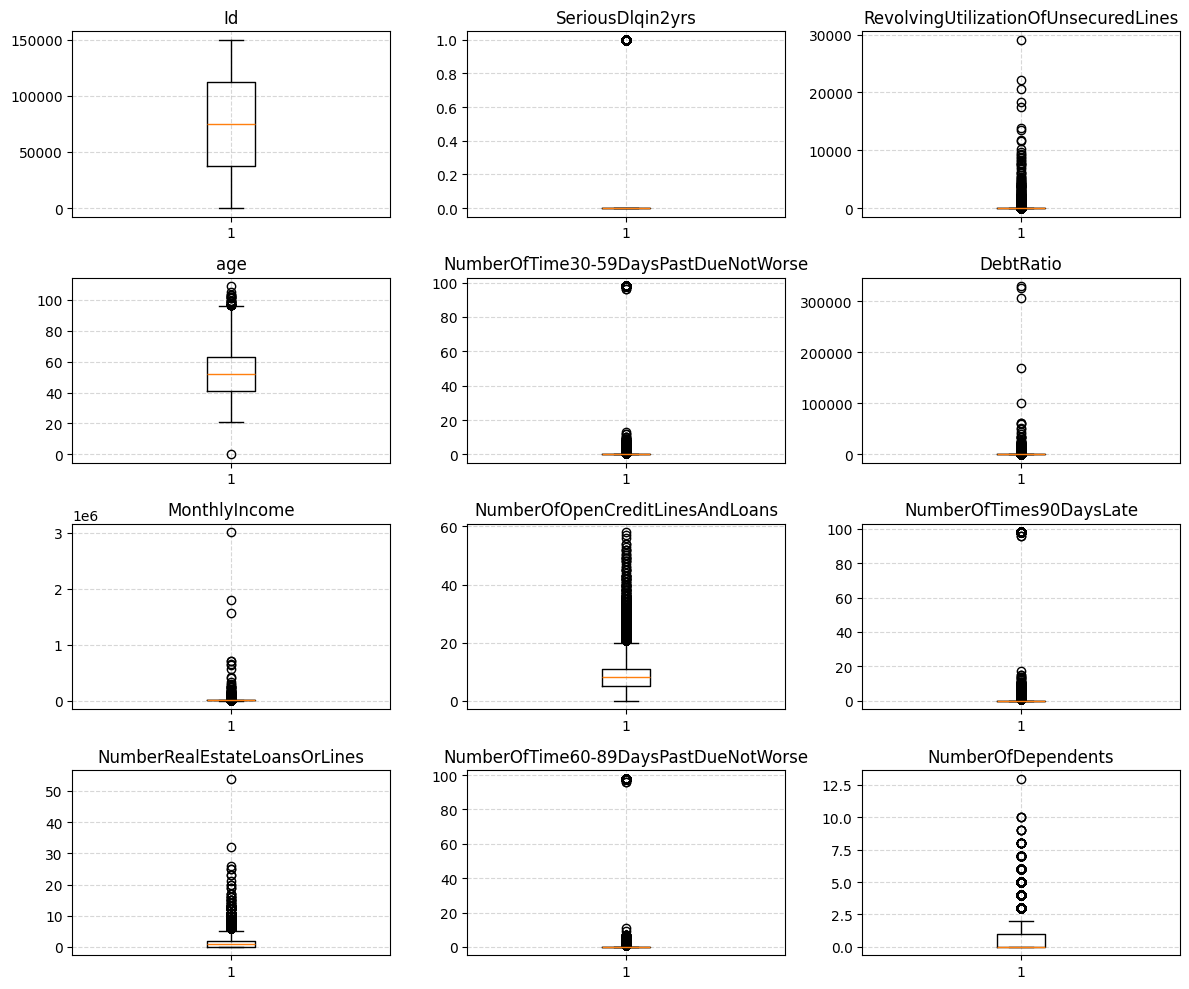

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(12, 10))
ax = ax.flatten()  # Aplana la matriz 4x3 a un array 1D para iterar fácilmente

for i, col in enumerate(df_train.columns):
    if i < len(ax):
        # dropna() evita errores si hay valores faltantes
        ax[i].boxplot(df_train[col].dropna())
        ax[i].set_title(col)
        ax[i].grid(True, linestyle='--', alpha=0.5)

# Oculta los subplots sobrantes si hay menos columnas que ejes
for j in range(len(df_train.columns), len(ax)):
    ax[j].set_visible(False)

plt.tight_layout()
plt.show()

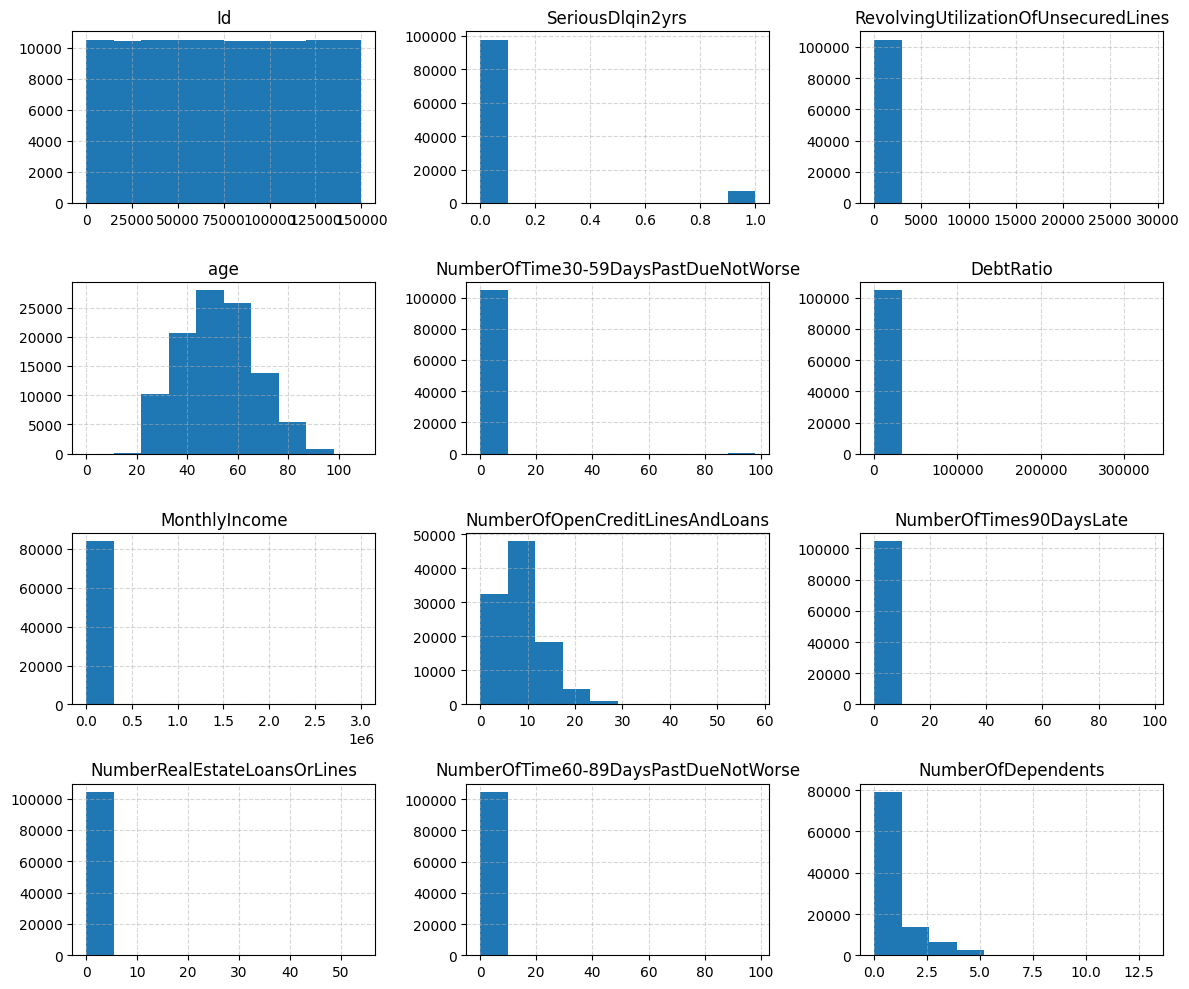

In [30]:
fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(12, 10))
ax = ax.flatten()  # Aplana la matriz 4x3 a un array 1D para iterar fácilmente

for i, col in enumerate(df_train.columns):
    if i < len(ax):
        # dropna() evita errores si hay valores faltantes
        ax[i].hist(df_train[col].dropna())
        ax[i].set_title(col)
        ax[i].grid(True, linestyle='--', alpha=0.5)

# Oculta los subplots sobrantes si hay menos columnas que ejes
for j in range(len(df_train.columns), len(ax)):
    ax[j].set_visible(False)

plt.tight_layout()
plt.show()

### 3.4 Conclusiones del Análisis Exploratorio

A partir de los boxplots y los histogramas, se identifican los siguientes hallazgos clave:

1. **`age`:** Existen registros con edad = 0, lo cual es un error de datos. Se eliminarán o imputarán con la mediana.
2. **`NumberOfTime30-59DaysPastDueNotWorse`**, **`NumberOfTime60-89DaysPastDueNotWorse`** y **`NumberOfTimes90DaysLate`:**  
   Presentan valores extremos (por ejemplo, 96 y 98) que, dado el contexto de una ventana de 2 años (24 meses), son **físicamente imposibles**. Estos valores deben limitarse (capping) a 24.
3. **`RevolvingUtilizationOfUnsecuredLines`** y **`DebtRatio`:**  
   Distribuciones altamente sesgadas con colas largas. Se aplicará una **transformación logarítmica** (`log1p`) para normalizarlas.
4. **`MonthlyIncome`:**  
   Contiene valores nulos y una distribución muy sesgada. Requiere imputación y transformación logarítmica.
5. **`NumberOfDependents`:**  
   Valores nulos que se imputarán mediante MICE.

## 4. Limpieza y Transformación de Datos

En esta fase aplicaremos las siguientes transformaciones basadas en los hallazgos del EDA:

| Paso | Variable(s) | Acción |
|------|-------------|--------|
| 4.1 | `age` | Reemplazo de valores 0 por la mediana |
| 4.2 | Columnas de retraso | Capping a 24 (máximo teórico en 2 años) |
| 4.3 | `MonthlyIncome`, `DebtRatio`, `RevolvingUtilizationOfUnsecuredLines` | Transformación logarítmica (`log1p`) |
| 4.4 | `MonthlyIncome` | Creación de flag indicador de nulidad |
| 4.5 | `MonthlyIncome`, `NumberOfDependents` | Imputación multivariada (MICE) |

In [15]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 104806 entries, 0 to 104805
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Id                                    104805 non-null  Int64  
 1   SeriousDlqin2yrs                      104805 non-null  Int8   
 2   RevolvingUtilizationOfUnsecuredLines  104805 non-null  float32
 3   age                                   104805 non-null  Int32  
 4   NumberOfTime30-59DaysPastDueNotWorse  104805 non-null  Int32  
 5   DebtRatio                             104805 non-null  float32
 6   MonthlyIncome                         84024 non-null   float32
 7   NumberOfOpenCreditLinesAndLoans       104805 non-null  Int32  
 8   NumberOfTimes90DaysLate               104805 non-null  Int32  
 9   NumberRealEstateLoansOrLines          104805 non-null  Int32  
 10  NumberOfTime60-89DaysPastDueNotWorse  104805 non-null  Int32  
 11  NumberOfDep

### 4.1 Tratamiento de `age`
Reemplazamos los valores de edad igual a **0** con la **mediana** de las edades válidas.  
Se utiliza la mediana en lugar de la media para minimizar la influencia de outliers en la distribución de edades.

In [20]:
df_train_clean = df_train.copy()
# Calculamos la mediana excluyendo los valores de 0
mediana_edad = df_train_clean.loc[df_train_clean['age'] > 0, 'age'].median()

# Reemplazamos los ceros con la mediana calculada
df_train_clean.loc[df_train_clean['age'] == 0, 'age'] = mediana_edad

print(f"Edad 0 reemplazada por la mediana: {mediana_edad}")

Edad 0 reemplazada por la mediana: 52.0


### 4.2 Capping de Variables de Retraso

Las tres columnas de retrasos evalúan el comportamiento de pago en una ventana de **2 años (24 meses)**.  
Si un cliente se atrasa entre 30 y 59 días, ese evento consume al menos **1 mes** del período de observación.  

Por lo tanto, el valor **máximo teórico** para cada una de estas variables es **24**.  
Cualquier valor superior a 24 se considera un **error de datos** y será reemplazado por 24.

> 📌 **Nota:** Utilizamos el valor 24 como umbral superior (capping) para conservar la señal de alto riesgo sin introducir ruido por valores imposibles.

In [32]:
# Definimos las columnas de retrasos
columnas_retrasos = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

# Reemplazamos valores mayores a 90 por NaN
for col in columnas_retrasos:
    # Contamos cuántos había para documentar
    cantidad_errores = len(df_train_clean[df_train_clean[col] > 90])
    df_train_clean.loc[df_train_clean[col] > 90, col] = np.nan
    print(f"Columna {col}: {cantidad_errores} códigos de error convertidos a NaN")

Columna NumberOfTime30-59DaysPastDueNotWorse: 183 códigos de error convertidos a NaN
Columna NumberOfTime60-89DaysPastDueNotWorse: 183 códigos de error convertidos a NaN
Columna NumberOfTimes90DaysLate: 183 códigos de error convertidos a NaN


### 4.3 Transformación Logarítmica de Variables con Distribución Sesgada

Aplicamos `np.log1p()` (que calcula `ln(1 + x)`) a las variables con distribuciones de **cola larga**:
- `MonthlyIncome`
- `DebtRatio`
- `RevolvingUtilizationOfUnsecuredLines`

> 💡 Se usa `log1p` en lugar de `log` porque si un cliente tiene un valor de 0, `log(0)` produce `-inf`, mientras que `log1p(0) = 0`, manteniendo la estabilidad numérica.

Las columnas transformadas se crean como **nuevas columnas** con el sufijo `_log` para preservar los datos originales.

In [33]:
# Definimos las columnas con distribuciones de cola larga
columnas_log = [
    'MonthlyIncome', 
    'DebtRatio', 
    'RevolvingUtilizationOfUnsecuredLines'
]

# Aplicamos np.log1p creando nuevas columnas
for col in columnas_log:
    # Aplicamos la transformación. Nota: para MonthlyIncome que tiene NaN,
    # np.log1p mantendrá los NaN intactos para imputarlos después.
    df_train_clean[col] = np.log1p(df_train_clean[col])

### 4.4 Creación del Flag `MonthlyIncome_Missing`

Agregamos una columna binaria indicadora que señala si el valor original de `MonthlyIncome` era nulo:  
- **1** = el ingreso estaba ausente (dato faltante).  
- **0** = el ingreso estaba presente.  

> 💡 **Justificación:** El hecho de que un cliente no haya reportado su ingreso puede ser en sí mismo una señal predictiva de riesgo. Al crear este flag, le damos al modelo la capacidad de aprender esta relación.

In [35]:
df_train_clean['MonthlyIncome_Missing'] = df_train_clean['MonthlyIncome'].apply(lambda x: 1 if pd.isna(x) else 0)

In [36]:
df_train_clean[['MonthlyIncome_Missing','MonthlyIncome']].head(10)

,MonthlyIncome_Missing,MonthlyIncome
0,0,7.863651
1,0,8.020599
2,0,8.101981
3,0,11.060196
4,0,8.160804
5,1,NaN
6,0,8.160804
7,1,NaN
8,0,7.824446
9,0,8.779865


### 4.5 Imputación Multivariada — MICE (Multiple Imputation by Chained Equations)

Utilizamos el `IterativeImputer` de scikit-learn con un estimador `BayesianRidge` para imputar los valores faltantes de `MonthlyIncome` y `NumberOfDependents`.  

A diferencia de la imputación simple (media/mediana), **MICE** modela cada variable con valores faltantes como una función de las demás variables, lo que:
- Preserva las **correlaciones** entre variables.
- Produce estimaciones más **realistas** y menos sesgadas.

Variables predictoras utilizadas en la imputación: `age`, `DebtRatio` y las propias variables a imputar.

In [ ]:
## Aplicacion de Inputacion Multivariada(MICE por su siglas en ingles)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

# 1. Seleccionar las columnas involucradas en la imputación
cols_impute = ['MonthlyIncome', 'age', 'DebtRatio', 'NumberOfDependents']
df_subset = df_train_clean[cols_impute].copy()

# 2. Convertir a float64 y pasar <NA> (pandas) a np.nan (numpy/sklearn)
# IterativeImputer requiere matrices numéricas sin el tipo nullable de pandas
df_subset = df_subset.astype('float64')

# 3. Configurar MICE con un estimador robusto para datos tabulares
imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    max_iter=10,          # Número de rondas de imputación (10 suele ser suficiente)
    random_state=42,      # Reproducibilidad
    sample_posterior=False, # False = imputación determinista (recomendado para ML)
    skip_complete=True    # Ignora filas sin nulos para acelerar
)

# 4. Ajustar y transformar
imputed_array = imputer.fit_transform(df_subset)

# 5. Reemplazar SOLO MonthlyIncome en el DataFrame original
df_train_clean['MonthlyIncome'] = imputed_array[:, 0]

# Verificación rápida
print("Nulos en MonthlyIncome después de imputar:", df_train_clean['MonthlyIncome'].isna().sum())
print("Rango de valores imputados:", df_train_clean['MonthlyIncome'].describe())

Nulos en MonthlyIncome después de imputar: 0
Rango de valores imputados: count    104806.000000
mean          6.942961
std           3.321430
min           0.000000
25%           7.469226
50%           8.380113
75%           8.909370
max          14.917036
Name: MonthlyIncome, dtype: float64


c:\Users\Diego Roman\Documents\Portafolio\Give Me Some Credit\.venv\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Aplicamos el mismo proceso de imputación MICE a la variable `NumberOfDependents`, utilizando las mismas variables predictoras.

In [ ]:
# 1. Seleccionar las columnas involucradas en la imputación
cols_impute = ['NumberOfDependents', 'age', 'DebtRatio', 'NumberOfDependents']
df_subset = df_train_clean[cols_impute].copy()

# 2. Convertir a float64 y pasar <NA> (pandas) a np.nan (numpy/sklearn)
# IterativeImputer requiere matrices numéricas sin el tipo nullable de pandas
df_subset = df_subset.astype('float64')

# 3. Ajustar y transformar
imputed_array = imputer.fit_transform(df_subset)

# 4. Reemplazar SOLO NumberOfDependents en el DataFrame original
df_train_clean['NumberOfDependents'] = imputed_array[:, 0]

# Verificación rápida
print("Nulos en NumberOfDependents después de imputar:", df_train_clean['NumberOfDependents'].isna().sum())
print("Rango de valores imputados:", df_train_clean['NumberOfDependents'].describe())

Nulos en NumberOfDependents después de imputar: 0
Rango de valores imputados: count    104806.000000
mean          0.762466
std           1.098166
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          13.000000
Name: NumberOfDependents, dtype: float64


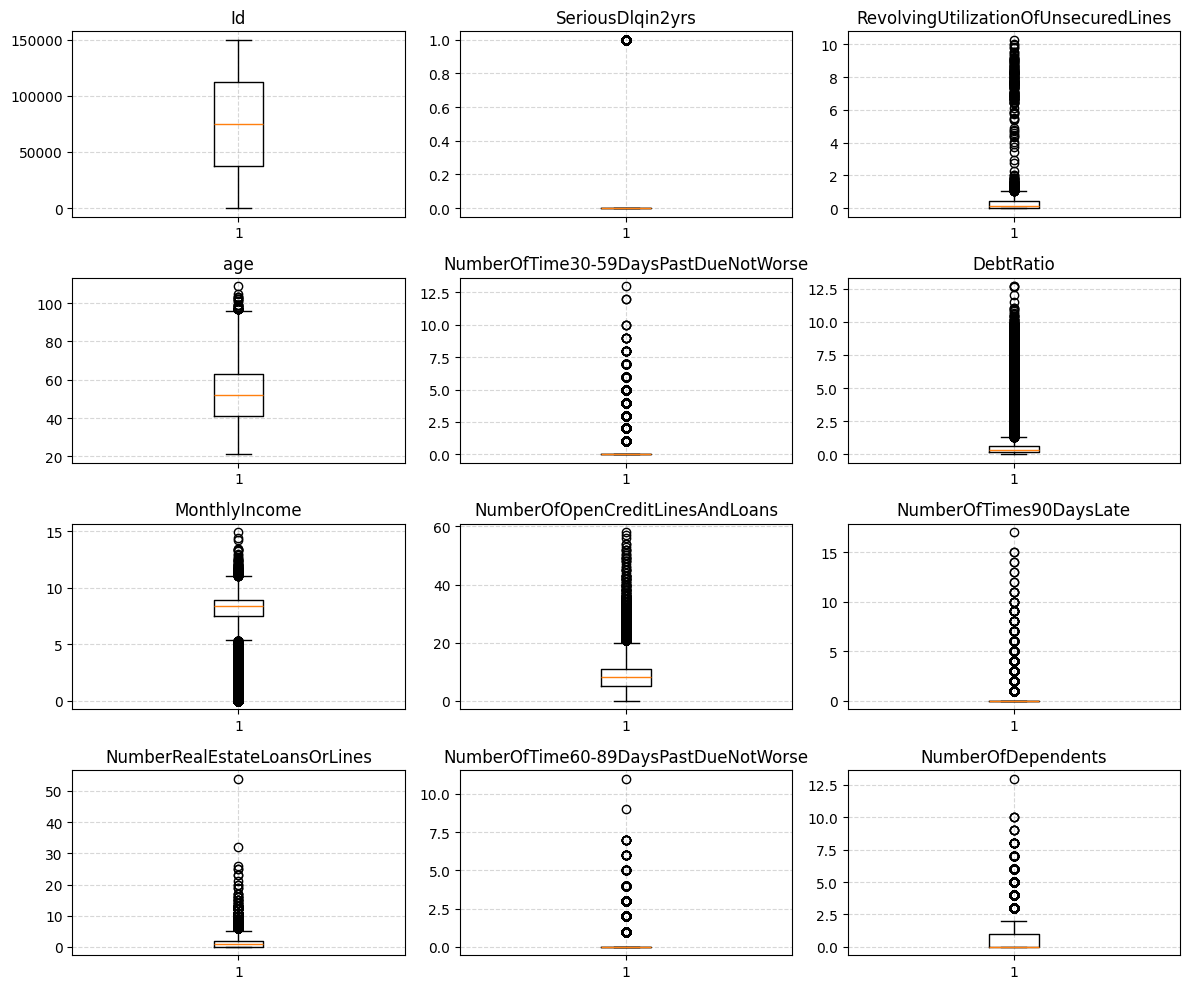

In [39]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(12, 10))
ax = ax.flatten()  # Aplana la matriz 4x3 a un array 1D para iterar fácilmente

for i, col in enumerate(df_train_clean.columns):
    if i < len(ax):
        # dropna() evita errores si hay valores faltantes
        ax[i].boxplot(df_train_clean[col].dropna())
        ax[i].set_title(col)
        ax[i].grid(True, linestyle='--', alpha=0.5)

# Oculta los subplots sobrantes si hay menos columnas que ejes
for j in range(len(df_train_clean.columns), len(ax)):
    ax[j].set_visible(False)

plt.tight_layout()
plt.show()

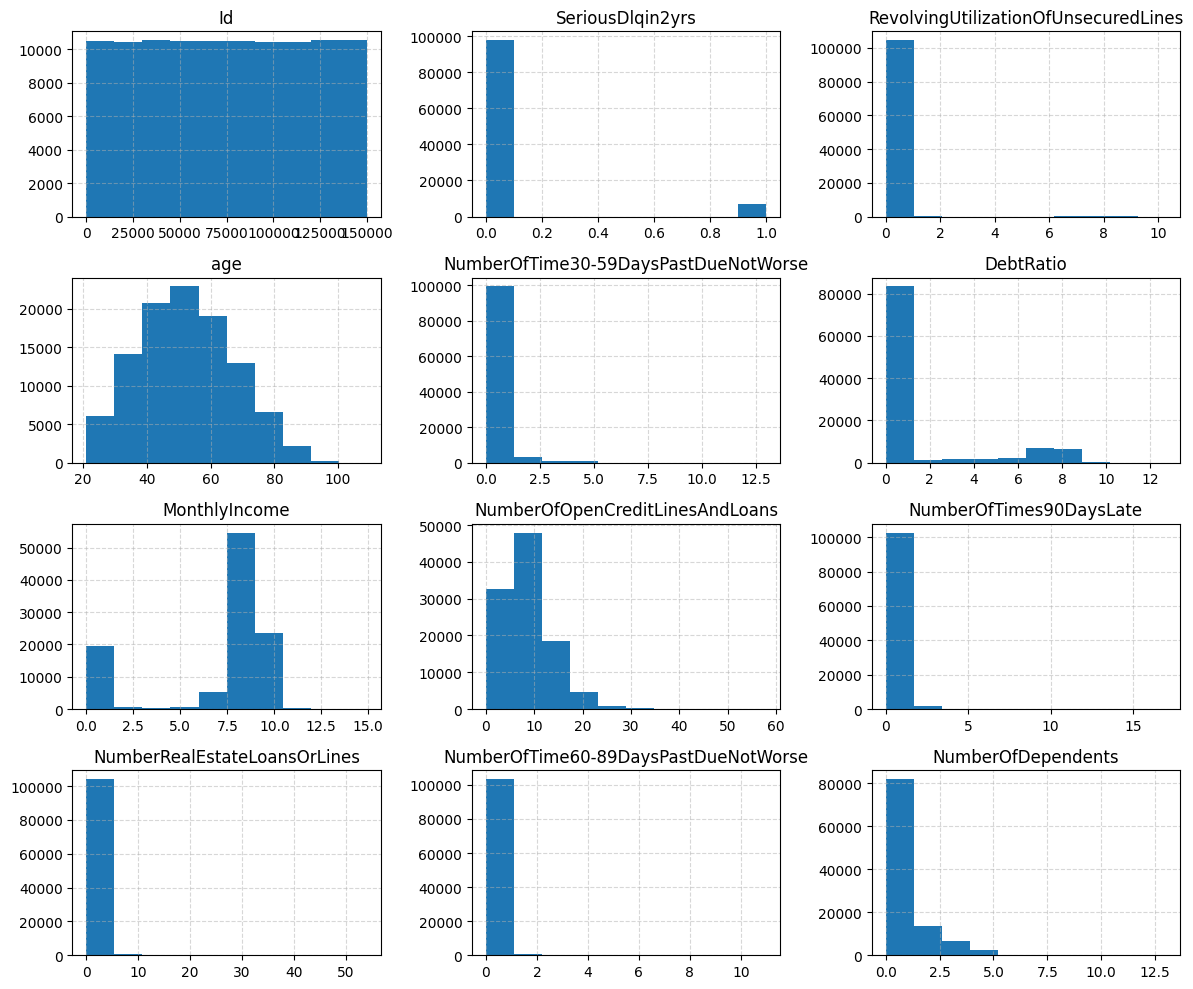

In [40]:
fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(12, 10))
ax = ax.flatten()  # Aplana la matriz 4x3 a un array 1D para iterar fácilmente

for i, col in enumerate(df_train_clean.columns):
    if i < len(ax):
        # dropna() evita errores si hay valores faltantes
        ax[i].hist(df_train_clean[col].dropna())
        ax[i].set_title(col)
        ax[i].grid(True, linestyle='--', alpha=0.5)

# Oculta los subplots sobrantes si hay menos columnas que ejes
for j in range(len(df_train_clean.columns), len(ax)):
    ax[j].set_visible(False)

plt.tight_layout()
plt.show()

## 5. Modelado Predictivo — XGBoost

Evaluaremos dos estrategias para manejar el **desbalanceo de clases** (la clase positiva `SeriousDlqin2yrs=1` es minoritaria):

| Estrategia | Descripción |
|------------|-------------|
| **Pesos Algorítmicos** | Se ajusta `scale_pos_weight` en XGBoost para compensar el desbalanceo |
| **SMOTE** | Se genera sobremuestreo sintético de la clase minoritaria antes del entrenamiento |

Ambos modelos serán optimizados con **Optuna** (optimización bayesiana de hiperparámetros) y evaluados mediante **AUC-ROC**.

### 5.1 Preprocesamiento del Dataset de Test
Para garantizar la **consistencia** entre los conjuntos de entrenamiento y prueba, encapsulamos todas las transformaciones de limpieza en una función reutilizable `limpiar_dataset_financiero()`.  
Esta función aplica exactamente los mismos pasos al dataset de test.

In [52]:
import pandas as pd
import numpy as np

def limpiar_dataset_financiero(df, mediana_edad_train=None):
    """
    Función que replica las transformaciones exactas del conjunto de entrenamiento.
    """
    df_clean = df.copy()
    
    # 1. Tratar Edad (usamos la mediana del TRAIN para evitar Data Leakage)
    if mediana_edad_train is None:
        mediana_edad_train = df_clean.loc[df_clean['age'] > 0, 'age'].median()
    df_clean.loc[df_clean['age'] == 0, 'age'] = mediana_edad_train
    
    # 2. Tratar Códigos de Error
    columnas_retrasos = [
        'NumberOfTime30-59DaysPastDueNotWorse',
        'NumberOfTime60-89DaysPastDueNotWorse',
        'NumberOfTimes90DaysLate'
    ]
    for col in columnas_retrasos:
        df_clean.loc[df_clean[col] > 90, col] = np.nan
        
    # 3. Transformaciones Logarítmicas
    columnas_log = ['MonthlyIncome', 'DebtRatio', 'RevolvingUtilizationOfUnsecuredLines']
    for col in columnas_log:
        df_clean[col] = np.log1p(df_clean[col])
        
    df_clean['MonthlyIncome_Missing'] = df_clean['MonthlyIncome'].apply(lambda x: 1 if pd.isna(x) else 0)
    cols_impute = ['MonthlyIncome', 'age', 'DebtRatio', 'NumberOfDependents']
    df_subset = df_clean[cols_impute].copy()
    df_subset = df_subset.astype('float64')

    # 3. Configurar MICE con un estimador robusto para datos tabulares
    imputer = IterativeImputer(
        estimator=RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
        max_iter=10,          # Número de rondas de imputación (10 suele ser suficiente)
        random_state=42,      # Reproducibilidad
        sample_posterior=False, # False = imputación determinista (recomendado para ML)
        skip_complete=True    # Ignora filas sin nulos para acelerar
    )

    # 4. Ajustar y transformar
    imputed_array = imputer.fit_transform(df_subset)

    # 5. Reemplazar SOLO MonthlyIncome en el DataFrame original
    df_clean['MonthlyIncome'] = imputed_array[:, 0]

    
    cols_impute = ['NumberOfDependents', 'age', 'DebtRatio', 'NumberOfDependents']
    df_subset = df_clean[cols_impute].copy()
    df_subset = df_subset.astype('float64')
    imputed_array = imputer.fit_transform(df_subset)

    df_clean['NumberOfDependents'] = imputed_array[:, 0]
    
    return df_clean

# Obtenemos la mediana del train para usarla en el test (evita sesgo poblacional)
mediana_edad_referencia = df_train_clean.loc[df_train_clean['age'] > 0, 'age'].median()

# APLICAMOS LA LIMPIEZA AL TEST
df_test_clean = limpiar_dataset_financiero(df_test, mediana_edad_train=mediana_edad_referencia)

In [53]:
df_test_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 45195 entries, 0 to 45194
Data columns (total 12 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Id                                    45195 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  45195 non-null  float64
 2   age                                   45195 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  45109 non-null  float64
 4   DebtRatio                             45195 non-null  float64
 5   MonthlyIncome                         45195 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       45195 non-null  int64  
 7   NumberOfTimes90DaysLate               45109 non-null  float64
 8   NumberRealEstateLoansOrLines          45195 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  45109 non-null  float64
 10  NumberOfDependents                    45195 non-null  float64
 11  MonthlyIncome_Missing     

In [54]:
df_train_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 104805 entries, 0 to 104804
Data columns (total 13 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Id                                    104805 non-null  Int64  
 1   SeriousDlqin2yrs                      104805 non-null  Int8   
 2   RevolvingUtilizationOfUnsecuredLines  104805 non-null  float32
 3   age                                   104805 non-null  Int32  
 4   NumberOfTime30-59DaysPastDueNotWorse  104622 non-null  Int32  
 5   DebtRatio                             104805 non-null  float32
 6   MonthlyIncome                         104805 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       104805 non-null  Int32  
 8   NumberOfTimes90DaysLate               104622 non-null  Int32  
 9   NumberRealEstateLoansOrLines          104805 non-null  Int32  
 10  NumberOfTime60-89DaysPastDueNotWorse  104622 non-null  Int32  
 11  NumberOfDep

### 5.2 XGBoost con Pesos Algorítmicos
Entrenamos un modelo XGBoost utilizando `scale_pos_weight` para compensar el desbalanceo de clases.  
El parámetro se calcula como la razón entre la cantidad de muestras negativas y positivas.

In [55]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df_train_clean = df_train_clean.dropna(subset=['SeriousDlqin2yrs'])

# Separar Features (X) y Target (y) del TRAIN LIMPIO
X = df_train_clean.drop(columns=['SeriousDlqin2yrs', 'Id'])
y = df_train_clean['SeriousDlqin2yrs']

# Hacemos el split local para evaluación
X_train_local, X_val_local, y_train_local, y_val_local = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Calcular pesos de clases para el desbalance
peso_balanceo = y_train_local.value_counts()[0] / y_train_local.value_counts()[1]

# Configurar el modelo XGBoost
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=peso_balanceo,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    use_label_encoder=False,
    eval_metric='auc'
)

# Entrenar modelo
xgb_model.fit(X_train_local, y_train_local)

# EVALUACIÓN DE PRECISIÓN LOCAL
y_val_pred = xgb_model.predict(X_val_local)
y_val_proba = xgb_model.predict_proba(X_val_local)[:, 1]

print("=== REPORTE DE CLASIFICACIÓN (EVALUACIÓN LOCAL) ===")
print(classification_report(y_val_local, y_val_pred, target_names=['Buen Pagador (0)', 'Impago (1)']))
print(f"ROC-AUC Local: {roc_auc_score(y_val_local, y_val_proba):.4f}")

c:\Users\Diego Roman\Documents\Portafolio\Give Me Some Credit\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:32:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== REPORTE DE CLASIFICACIÓN (EVALUACIÓN LOCAL) ===
                  precision    recall  f1-score   support

Buen Pagador (0)       0.98      0.81      0.88     19571
      Impago (1)       0.22      0.77      0.34      1390

        accuracy                           0.80     20961
       macro avg       0.60      0.79      0.61     20961
    weighted avg       0.93      0.80      0.85     20961

ROC-AUC Local: 0.8664


In [56]:
# Reentrenar con TODO el dataset limpio de entrenamiento para maximizar el aprendizaje
print("\nReentrenando con el 100% de los datos de Train...")
xgb_model.fit(X, y)

# Predecir sobre el df_test_clean
# Nos aseguramos de eliminar el Id si lo tiene, para que las columnas coincidan
X_test_final = df_test_clean.drop(columns=['Id', 'SeriousDlqin2yrs'], errors='ignore')

# Kaggle evalúa en base a las PROBABILIDADES de impago, no la clase absoluta
probabilidades_test = xgb_model.predict_proba(X_test_final)[:, 1]

# Crear el DataFrame para enviar a Kaggle
submission = pd.DataFrame({
    'Id': df_test_clean['Id'],
    'Probability': probabilidades_test
})

# Guardar el CSV
submission.to_csv('my_xgboost_submission.csv', index=False)
print("Archivo 'my_xgboost_submission.csv' generado con éxito y listo para Kaggle.")


Reentrenando con el 100% de los datos de Train...


c:\Users\Diego Roman\Documents\Portafolio\Give Me Some Credit\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:32:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Archivo 'my_xgboost_submission.csv' generado con éxito y listo para Kaggle.


### 5.3 Optimización de Hiperparámetros con Optuna

**Optuna** realiza una búsqueda bayesiana inteligente del espacio de hiperparámetros, aprendiendo de iteraciones anteriores para converger más rápido al óptimo.  

Se utiliza **validación cruzada estratificada (StratifiedKFold)** con la métrica **AUC-ROC** como función objetivo.

In [57]:
import optuna
import xgboost as xgb
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
import numpy as np

# Definimos la "función objetivo" que Optuna intentará maximizar
def objective(trial):
    # 1. Sugerimos un rango de hiperparámetros para que Optuna explore
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': peso_balanceo, # Mantenemos el peso que calculamos antes
        'eval_metric': 'auc',
        'random_state': 42,
        'use_label_encoder': False,
        'n_jobs': -1 # Usa todos los núcleos de tu procesador
    }
    
    # 2. Validación Cruzada (Cross-Validation)
    # Entrenamos en 5 cortes diferentes para asegurar que el modelo no memorice
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []
    
    for train_idx, val_idx in skf.split(X, y):
        X_fold_train, X_fold_val = X.iloc[train_idx], X.iloc[val_idx]
        y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Entrenamos el modelo con los parámetros sugeridos
        model = xgb.XGBClassifier(**params)
        model.fit(X_fold_train, y_fold_train, verbose=False)
        
        # Evaluamos
        pred_proba = model.predict_proba(X_fold_val)[:, 1]
        auc_scores.append(roc_auc_score(y_fold_val, pred_proba))
        
    # Devolvemos el promedio del AUC de los 5 cortes
    return np.mean(auc_scores)

# 3. Ejecutamos el estudio de Optuna
print("Iniciando la cacería de los mejores hiperparámetros...")
# direction='maximize' porque queremos el AUC más alto posible
study = optuna.create_study(direction='maximize') 

# n_trials=20 es un buen inicio. En producción real podrías dejarlo en 100.
study.optimize(objective, n_trials=20) 

print("\n=== LOS MEJORES HIPERPARÁMETROS ENCONTRADOS ===")
print(study.best_params)
print(f"Mejor ROC-AUC logrado: {study.best_value:.4f}")

# 4. Entrenar el modelo final con estos súper parámetros
best_xgb_model = xgb.XGBClassifier(
    **study.best_params, 
    scale_pos_weight=peso_balanceo,
    random_state=42
)
best_xgb_model.fit(X, y)
print("\nModelo final reentrenado y listo para producción.")

c:\Users\Diego Roman\Documents\Portafolio\Give Me Some Credit\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-28 20:39:59,170] A new study created in memory with name: no-name-7d9a32e5-4d72-40ee-9741-2c4bb3ed4dc6
c:\Users\Diego Roman\Documents\Portafolio\Give Me Some Credit\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:39:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Iniciando la cacería de los mejores hiperparámetros...


c:\Users\Diego Roman\Documents\Portafolio\Give Me Some Credit\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:40:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Diego Roman\Documents\Portafolio\Give Me Some Credit\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:40:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Diego Roman\Documents\Portafolio\Give Me Some Credit\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:40:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Diego Roman\Documents\Portafolio\Give Me Some Credit\.venv\Lib\site-packages\xgboost\traini


=== LOS MEJORES HIPERPARÁMETROS ENCONTRADOS ===
{'n_estimators': 239, 'max_depth': 4, 'learning_rate': 0.044908710305634786, 'subsample': 0.6426720442488564, 'colsample_bytree': 0.6226174156335813}
Mejor ROC-AUC logrado: 0.8643

Modelo final reentrenado y listo para producción.


### 5.4 Explicabilidad del Modelo con SHAP

SHAP (SHapley Additive exPlanations) permite descomponer las predicciones del modelo y determinar la **contribución individual de cada variable**.  
Esto es esencial en el contexto financiero para:
- **Cumplir con regulaciones** que exigen transparencia en las decisiones crediticias.
- **Identificar las variables más influyentes** en la predicción de incumplimiento.
- **Validar que el modelo aprendió relaciones lógicas** (por ejemplo, mayor morosidad = mayor probabilidad de incumplimiento).

Calculando los valores SHAP (esto puede tomar un minuto)...


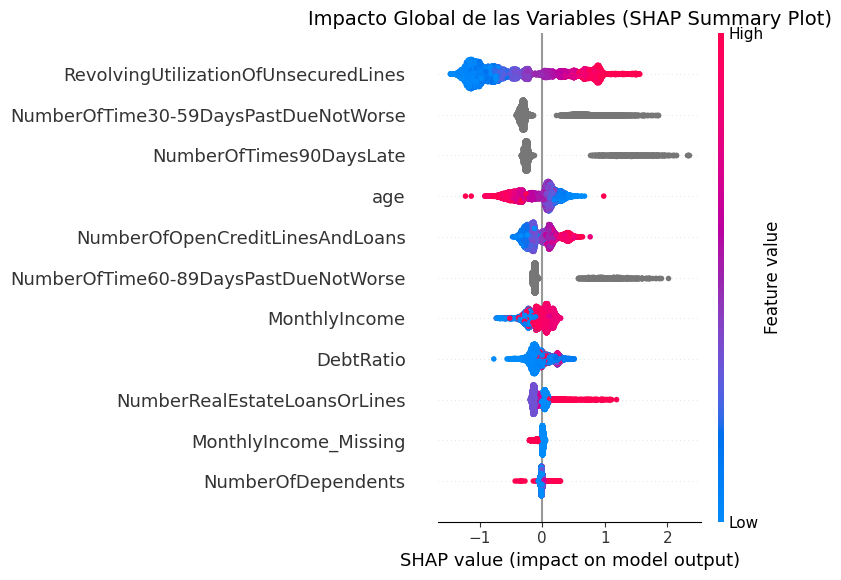


Generando explicación para un caso de Denegación de Crédito...


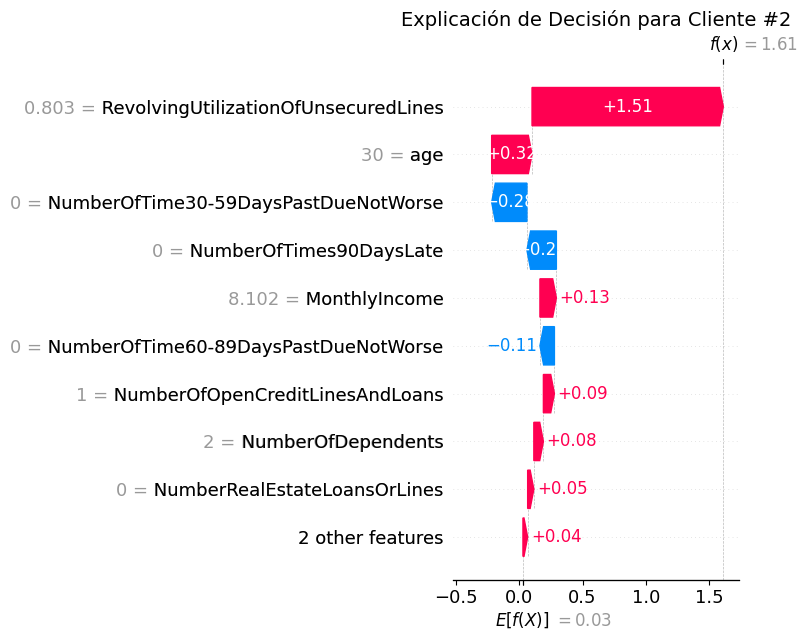

In [58]:
import shap
import matplotlib.pyplot as plt

# 1. Inicializar el Explainer de SHAP
print("Calculando los valores SHAP (esto puede tomar un minuto)...")
# Usamos TreeExplainer porque es ultra rápido y específico para XGBoost/Random Forest
explainer = shap.TreeExplainer(best_xgb_model)

# SHAP necesita mucha memoria, por lo que para gráficas a veces se toma una muestra (ej. 10,000 filas)
# Si tu PC tiene buena RAM (como los 32GB que actualizaste), puedes pasarle el X_val_local completo.
X_sample = X_val_local.sample(n=10000, random_state=42) 
shap_values = explainer(X_sample)

# 2. GRÁFICA 1: Summary Plot (El "Beeswarm" plot)
# Te dice qué variables son más importantes y cómo afectan la predicción
plt.figure(figsize=(10, 8))
plt.title("Impacto Global de las Variables (SHAP Summary Plot)", fontsize=14)
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.show()

# 3. GRÁFICA 2: Waterfall Plot (Explicando a un cliente individual)
# Busquemos a alguien que el modelo haya predicho como "Impago" (Riesgo Alto)
predicciones_muestra = best_xgb_model.predict(X_sample)
indices_morosos = np.where(predicciones_muestra == 1)[0]

if len(indices_morosos) > 0:
    # Tomamos al primer cliente riesgoso de la lista
    cliente_idx = indices_morosos[0]
    
    print("\nGenerando explicación para un caso de Denegación de Crédito...")
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_values[cliente_idx], max_display=10, show=False)
    plt.title(f"Explicación de Decisión para Cliente #{cliente_idx}", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron casos de impago en la muestra para graficar.")

### 5.5 XGBoost con SMOTE (Synthetic Minority Over-sampling Technique)

En esta estrategia alternativa, **generamos muestras sintéticas** de la clase minoritaria para equilibrar el dataset antes del entrenamiento.  

> ⚠️ **Importante:** SMOTE solo se aplica sobre los datos de **entrenamiento**, nunca sobre los de validación o test, para evitar data leakage.

In [61]:
import pandas as pd
from sklearn.experimental import enable_iterative_imputer # Necesario para activar IterativeImputer
from sklearn.impute import IterativeImputer
from imblearn.over_sampling import SMOTE

print("1. Iniciando Imputación Multivariada (MICE) para rellenar NaNs...")

# Configuramos el imputador multivariado
# max_iter=10 es un buen balance entre velocidad y precisión
imputador_mice = IterativeImputer(random_state=42, max_iter=10)

# ENTRENAMOS y transformamos SOLO en el conjunto de entrenamiento
# Nota: IterativeImputer devuelve un array de numpy, así que lo volvemos a convertir a DataFrame
X_train_imputed = pd.DataFrame(
    imputador_mice.fit_transform(X_train_local), 
    columns=X_train_local.columns
)

# TRANSFORMAMOS el conjunto de validación (usando lo que aprendió del train)
X_val_imputed = pd.DataFrame(
    imputador_mice.transform(X_val_local), 
    columns=X_val_local.columns
)

print("Imputación completada. Cero NaNs restantes en X_train_imputed.")

# -------------------------------------------------------------------

print(f"\n2. Distribución ANTES de SMOTE:\n{y_train_local.value_counts()}")

# Ahora sí, aplicamos SMOTE sobre la data imputada (sin nulos)
smote = SMOTE(random_state=42)

# Usamos X_train_imputed en lugar de X_train_local
X_train_smote, y_train_smote = smote.fit_resample(X_train_imputed, y_train_local)

print(f"\n3. Distribución DESPUÉS de SMOTE:\n{y_train_smote.value_counts()}")

1. Iniciando Imputación Multivariada (MICE) para rellenar NaNs...
Imputación completada. Cero NaNs restantes en X_train_imputed.

2. Distribución ANTES de SMOTE:
SeriousDlqin2yrs
0    78284
1     5560
Name: count, dtype: Int64

3. Distribución DESPUÉS de SMOTE:
SeriousDlqin2yrs
0    78284
1    78284
Name: count, dtype: Int64


Entrenando XGBoost con datos balanceados por SMOTE...


c:\Users\Diego Roman\Documents\Portafolio\Give Me Some Credit\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:03:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== REPORTE DE CLASIFICACIÓN (XGBoost + SMOTE) ===
                  precision    recall  f1-score   support

Buen Pagador (0)       0.96      0.96      0.96     19571
      Impago (1)       0.42      0.37      0.39      1390

        accuracy                           0.92     20961
       macro avg       0.69      0.67      0.68     20961
    weighted avg       0.92      0.92      0.92     20961

ROC-AUC Local (SMOTE): 0.8444


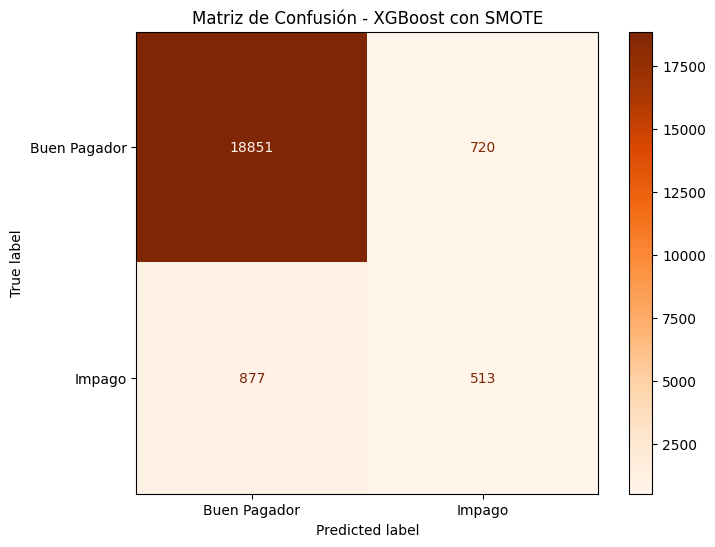

In [62]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Instanciar XGBoost SIN scale_pos_weight
xgb_smote_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,             # Mantenemos profundidad baja para no sobreajustar la data sintética
    learning_rate=0.05,
    random_state=42,
    use_label_encoder=False,
    eval_metric='auc'
)

# 2. Entrenar con la data sintética (SMOTE)
print("Entrenando XGBoost con datos balanceados por SMOTE...")
xgb_smote_model.fit(X_train_smote, y_train_smote)

# 3. Validar con la data de validación ORIGINAL (X_val_local)
# CRÍTICO: La validación siempre se hace en datos reales, sin SMOTE.
y_val_pred_smote = xgb_smote_model.predict(X_val_local)
y_val_proba_smote = xgb_smote_model.predict_proba(X_val_local)[:, 1]

# 4. Evaluación
print("\n=== REPORTE DE CLASIFICACIÓN (XGBoost + SMOTE) ===")
print(classification_report(y_val_local, y_val_pred_smote, target_names=['Buen Pagador (0)', 'Impago (1)']))
print(f"ROC-AUC Local (SMOTE): {roc_auc_score(y_val_local, y_val_proba_smote):.4f}")

# Graficar para tu reporte comparativo
cm = confusion_matrix(y_val_local, y_val_pred_smote)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Buen Pagador', 'Impago'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Oranges', ax=ax, values_format='d') # Usamos Naranja para diferenciarlo del anterior
plt.title('Matriz de Confusión - XGBoost con SMOTE')
plt.show()

In [63]:
import pandas as pd

print("Preparando datos de prueba y generando predicciones...")

# 1. Asegurarnos de que las columnas coincidan exactamente (quitamos Id y target si existen)
X_test_final = df_test_clean.drop(columns=['Id', 'SeriousDlqin2yrs'], errors='ignore')

# 2. Imputar los nulos en TEST usando el imputador previamente ajustado (fit) en TRAIN
# CRÍTICO: Usamos .transform(), NUNCA .fit_transform() en la data de test
X_test_imputed = pd.DataFrame(
    imputador_mice.transform(X_test_final),
    columns=X_test_final.columns
)

# 3. Predecir probabilidades (la métrica que pide Kaggle) usando el modelo entrenado con SMOTE
probabilidades_test = xgb_smote_model.predict_proba(X_test_imputed)[:, 1]

# 4. Crear el DataFrame para enviar a Kaggle
submission = pd.DataFrame({
    'Id': df_test_clean['Id'],
    'Probability': probabilidades_test
})

# Guardar el CSV
submission.to_csv('submission_xgboost_smote.csv', index=False)
print("Archivo 'submission_xgboost_smote.csv' generado con éxito y listo para subir.")

Preparando datos de prueba y generando predicciones...
Archivo 'submission_xgboost_smote.csv' generado con éxito y listo para subir.


In [65]:
import optuna
import xgboost as xgb
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline # CRÍTICO: Usar el pipeline de imblearn, no el de sklearn
import numpy as np

print("Iniciando motor de optimización Optuna con SMOTE dinámico...")

# 1. Definir la función objetivo para Optuna
def objective(trial):
    # Sugerimos el espacio de búsqueda de hiperparámetros
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'eval_metric': 'auc',
        'random_state': 42,
        'n_jobs': -1 
        # IMPORTANTE: Eliminamos scale_pos_weight porque SMOTE ya hace el balanceo
    }
    
    # Configuramos Validación Cruzada de 5 cortes
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []
    
    # Iteramos sobre los cortes usando la data IMPUTADA (sin nulos)
    for train_idx, val_idx in skf.split(X_train_imputed, y_train_local):
        X_fold_train, X_fold_val = X_train_imputed.iloc[train_idx], X_train_imputed.iloc[val_idx]
        y_fold_train, y_fold_val = y_train_local.iloc[train_idx], y_train_local.iloc[val_idx]
        
        # 2. LA MAGIA DEL PIPELINE:
        # Esto asegura que SMOTE se calcule SOLO usando el X_fold_train
        # en cada uno de los 5 intentos, evitando que el modelo memorice el ruido.
        pipeline = Pipeline([
            ('smote', SMOTE(random_state=42)),
            ('classifier', xgb.XGBClassifier(**params))
        ])
        
        # Entrenamos el pipeline completo
        pipeline.fit(X_fold_train, y_fold_train)
        
        # Evaluamos en el fold de validación (que NUNCA fue tocado por SMOTE)
        pred_proba = pipeline.predict_proba(X_fold_val)[:, 1]
        auc = roc_auc_score(y_fold_val, pred_proba)
        auc_scores.append(auc)
        
    return np.mean(auc_scores)

# 3. Ejecutar el Estudio
# direction='maximize' porque buscamos el ROC-AUC más alto (cercano a 1.0)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20) # Sube a 50 si tienes tiempo de cómputo

print("\n" + "="*50)
print("🏆 OPTIMIZACIÓN FINALIZADA 🏆")
print(f"Mejor ROC-AUC logrado en Validación Cruzada: {study.best_value:.4f}")
print("Mejores hiperparámetros encontrados:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")
print("="*50)

[I 2026-04-28 21:12:21,445] A new study created in memory with name: no-name-6cafda71-f29b-425f-b870-e9c560b96d27


Iniciando motor de optimización Optuna con SMOTE dinámico...


[I 2026-04-28 21:12:27,856] Trial 0 finished with value: 0.8447397793625717 and parameters: {'n_estimators': 406, 'max_depth': 5, 'learning_rate': 0.05607310168790991, 'subsample': 0.7412251590816646, 'colsample_bytree': 0.8567609910455991}. Best is trial 0 with value: 0.8447397793625717.
[I 2026-04-28 21:12:33,278] Trial 1 finished with value: 0.8395137240313927 and parameters: {'n_estimators': 290, 'max_depth': 6, 'learning_rate': 0.13024194412499202, 'subsample': 0.6866792312064935, 'colsample_bytree': 0.6177247946167128}. Best is trial 0 with value: 0.8447397793625717.
[I 2026-04-28 21:12:42,138] Trial 2 finished with value: 0.8462827687719621 and parameters: {'n_estimators': 485, 'max_depth': 6, 'learning_rate': 0.016082196971384376, 'subsample': 0.8004686435038338, 'colsample_bytree': 0.7025009219375331}. Best is trial 2 with value: 0.8462827687719621.
[I 2026-04-28 21:12:50,062] Trial 3 finished with value: 0.8461019964997423 and parameters: {'n_estimators': 426, 'max_depth': 6,


🏆 OPTIMIZACIÓN FINALIZADA 🏆
Mejor ROC-AUC logrado en Validación Cruzada: 0.8501
Mejores hiperparámetros encontrados:
  - n_estimators: 216
  - max_depth: 3
  - learning_rate: 0.037857419945963325
  - subsample: 0.7426418868348894
  - colsample_bytree: 0.8219856639695713


In [68]:
print("Entrenando el modelo XGBoost definitivo con los mejores hiperparámetros y SMOTE...")

# 1. Instanciamos el modelo con los parámetros ganadores de Optuna
best_xgb_smote_model = xgb.XGBClassifier(
    **study.best_params,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

# 2. Entrenamos usando el X_train_smote completo 
best_xgb_smote_model.fit(X_train_smote, y_train_smote)

print("¡Modelo entrenado y listo para exportar predicciones o graficar SHAP!")

Entrenando el modelo XGBoost definitivo con los mejores hiperparámetros y SMOTE...
¡Modelo entrenado y listo para exportar predicciones o graficar SHAP!


Calculando valores SHAP (esto puede tomar unos momentos)...


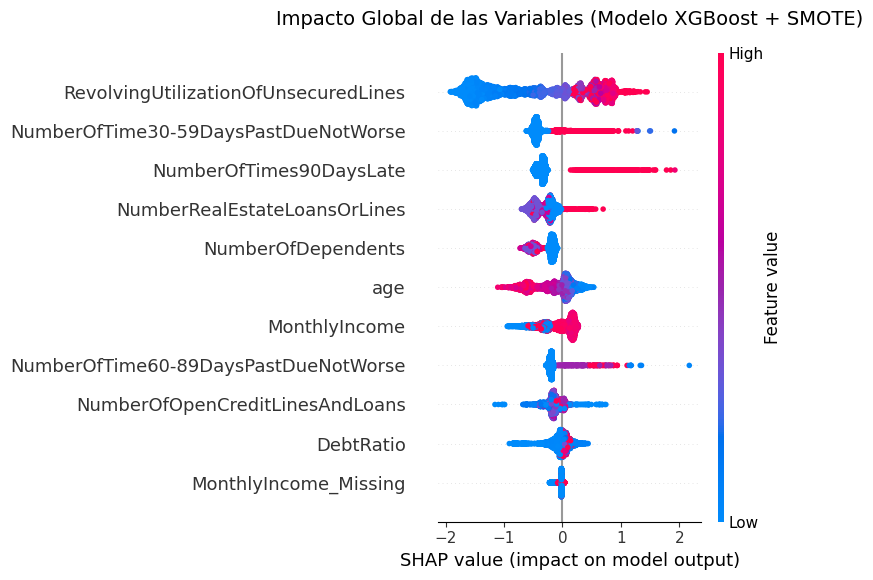


Generando explicación detallada para el Cliente de Alto Riesgo (Índice #2)...


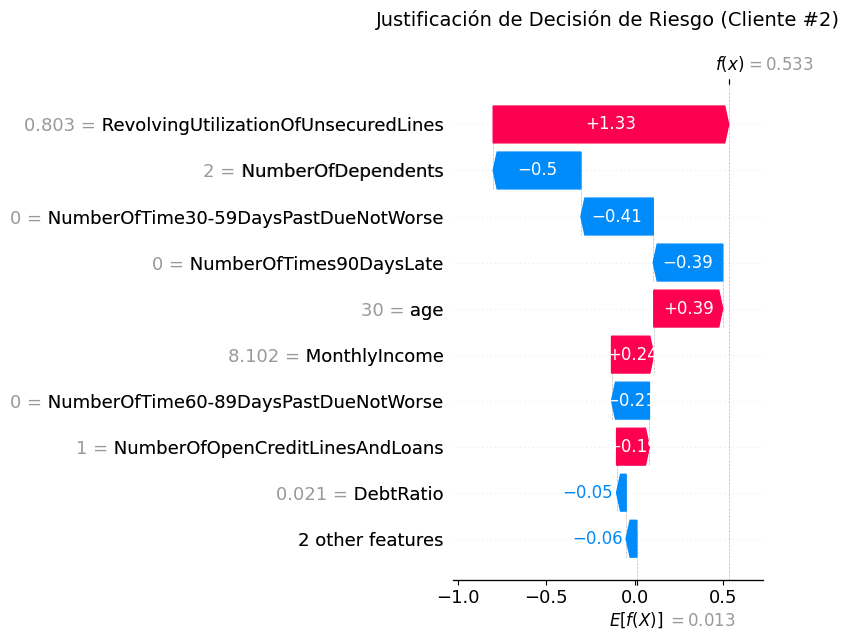

In [66]:
import shap
import matplotlib.pyplot as plt
import numpy as np

print("Calculando valores SHAP (esto puede tomar unos momentos)...")

# 1. Inicializar el Explainer con tu modelo SMOTE
explainer = shap.TreeExplainer(xgb_smote_model)

# Tomamos una muestra de la data de VALIDACIÓN (clientes reales) para acelerar el cálculo visual
X_shap_sample = X_val_imputed.sample(n=5000, random_state=42)
shap_values = explainer(X_shap_sample)

# --- GRÁFICO 1: SHAP Summary Plot (Impacto Global) ---
plt.figure(figsize=(10, 8))
# Usamos show=False para poder agregar título y layout personalizado
shap.summary_plot(shap_values, X_shap_sample, show=False)
plt.title("Impacto Global de las Variables (Modelo XGBoost + SMOTE)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# --- GRÁFICO 2: Waterfall Plot (Explicación Individual) ---
# Buscamos un cliente real de la muestra que el modelo haya clasificado como "Impago" (1)
predicciones_muestra = xgb_smote_model.predict(X_shap_sample)
indices_morosos = np.where(predicciones_muestra == 1)[0]

if len(indices_morosos) > 0:
    # Seleccionamos al primer cliente riesgoso
    cliente_idx = indices_morosos[0]
    
    print(f"\nGenerando explicación detallada para el Cliente de Alto Riesgo (Índice #{cliente_idx})...")
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_values[cliente_idx], max_display=10, show=False)
    plt.title(f"Justificación de Decisión de Riesgo (Cliente #{cliente_idx})", fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()
else:
    print("\nNo se detectaron clientes predichos como clase 1 en la muestra tomada.")

## 6. Exportación de Modelos (MLOps)

Guardamos los artefactos del modelo para su posterior despliegue o reutilización:
- **Imputador MICE** (`.joblib`) — necesario para preprocesar nuevos datos.
- **Modelo XGBoost con Pesos Algorítmicos** (`.json`) — formato nativo de XGBoost.
- **Modelo XGBoost con SMOTE** (`.json`) — formato nativo de XGBoost.

In [69]:
import joblib

print("=== INICIANDO EXPORTACIÓN DE MODELOS (MLOps) ===")

# ---------------------------------------------------------
# 1. GUARDAR EL PREPROCESADOR (CRÍTICO)
# ---------------------------------------------------------
# Guardamos el imputador MICE usando joblib
joblib.dump(imputador_mice, 'imputador_mice_financiero.joblib')
print("✅ Imputador MICE guardado exitosamente: 'imputador_mice_financiero.joblib'")

# ---------------------------------------------------------
# 2. GUARDAR MODELOS XGBOOST (NATIVO)
# ---------------------------------------------------------
# Guardar el modelo 1: XGBoost con pesos algorítmicos (scale_pos_weight)
# Asumiendo que la variable de tu mejor modelo se llama 'best_xgb_model'
best_xgb_model.save_model('xgboost_base_optimizado.json')
print("✅ Modelo XGBoost guardado: 'xgboost_base_optimizado.json'")

# Guardar el modelo 2: XGBoost entrenado con datos SMOTE
# Asumiendo que tu variable final es 'best_xgb_smote_model'
best_xgb_smote_model.save_model('xgboost_smote_optimizado.json')
print("✅ Modelo XGBoost+SMOTE guardado: 'xgboost_smote_optimizado.json'")

print("\nTodos los artefactos están listos para ser desplegados en producción.")

=== INICIANDO EXPORTACIÓN DE MODELOS (MLOps) ===
✅ Imputador MICE guardado exitosamente: 'imputador_mice_financiero.joblib'
✅ Modelo XGBoost guardado: 'xgboost_base_optimizado.json'
✅ Modelo XGBoost+SMOTE guardado: 'xgboost_smote_optimizado.json'

Todos los artefactos están listos para ser desplegados en producción.


In [70]:
import joblib
import xgboost as xgb

# 1. Cargar el imputador
imputador_cargado = joblib.load('imputador_mice_financiero.joblib')

# 2. Cargar el modelo XGBoost (Ejemplo cargando el de SMOTE)
modelo_cargado = xgb.XGBClassifier()
modelo_cargado.load_model('xgboost_smote_optimizado.json')

print("Modelo e Imputador cargados. Listo para predecir sobre nuevos clientes.")
# Ejemplo de uso: predicciones = modelo_cargado.predict_proba(nuevos_datos_imputados)

Modelo e Imputador cargados. Listo para predecir sobre nuevos clientes.


## 7. Evaluación Comparativa de Modelos

Comparamos ambas estrategias utilizando un conjunto completo de métricas:
- **AUC-ROC** — métrica principal para problemas de clasificación desbalanceados.
- **Accuracy**, **Precision**, **Recall** y **F1-Score** — métricas complementarias.
- **Curva ROC** — visualización del trade-off entre sensibilidad y especificidad.

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_curve
)

def evaluar_modelos_financieros(diccionario_modelos, X_val, y_val):
    """
    Evalúa múltiples modelos de clasificación y genera un reporte comparativo.
    
    Args:
        diccionario_modelos (dict): Formato {'Nombre Comercial': objeto_modelo}
        X_val (DataFrame): Conjunto de validación (features imputadas)
        y_val (Series): Etiquetas reales del conjunto de validación
        
    Returns:
        DataFrame: Tabla comparativa de métricas ordenadas por ROC-AUC.
    """
    resultados = []
    
    # Preparamos el lienzo para la Curva ROC comparativa
    plt.figure(figsize=(10, 8))
    
    print("Iniciando evaluación comparativa de modelos...\n")
    
    for nombre, modelo in diccionario_modelos.items():
        # 1. Generar predicciones (clase final y probabilidades)
        y_pred = modelo.predict(X_val)
        y_proba = modelo.predict_proba(X_val)[:, 1]
        
        # 2. Calcular Métricas Clave
        # Nos enfocamos en la clase 1 (Impago) porque es la que genera pérdidas al banco
        auc = roc_auc_score(y_val, y_proba)
        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        f1 = f1_score(y_val, y_pred, zero_division=0)
        
        # 3. Guardar en el registro
        resultados.append({
            'Modelo': nombre,
            'ROC-AUC': auc,
            'Recall (Morosos Detectados)': rec,
            'Precision (Falsas Alarmas)': prec,
            'F1-Score': f1,
            'Accuracy Global': acc
        })
        
        # 4. Graficar Curva ROC para este modelo
        fpr, tpr, _ = roc_curve(y_val, y_proba)
        plt.plot(fpr, tpr, lw=2, label=f'{nombre} (AUC = {auc:.4f})')

    # Configuración estética de la gráfica ROC
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Modelo Aleatorio')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
    plt.ylabel('Tasa de Verdaderos Positivos (TPR - Recall)', fontsize=12)
    plt.title('Comparativa de Curvas ROC - Detección de Impago', fontsize=14, pad=20)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 5. Convertir a DataFrame, estilizar y retornar
    df_resultados = pd.DataFrame(resultados).sort_values(by='ROC-AUC', ascending=False)
    
    # Redondeamos a 4 decimales para que se vea limpio
    return df_resultados.round(4).reset_index(drop=True)

Iniciando evaluación comparativa de modelos...



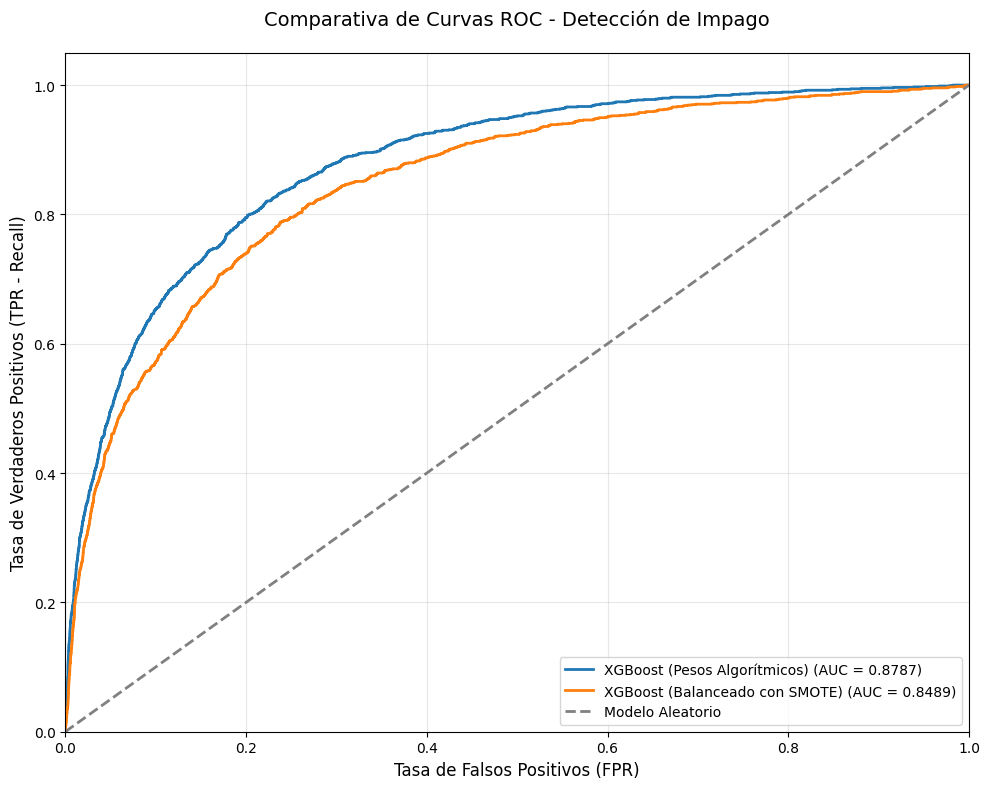


=== TABLA DE MÉTRICAS FINALES ===


,Modelo,ROC-AUC,Recall (Morosos Detectados),Precision (Falsas Alarmas),F1-Score,Accuracy Global
0,XGBoost (Pesos Algorítmicos),0.8787,0.7914,0.2212,0.3457,0.8014
1,XGBoost (Balanceado con SMOTE),0.8489,0.5180,0.3427,0.4125,0.9022


In [72]:
# Armamos el diccionario con los dos campeones que guardaste
mis_modelos = {
    'XGBoost (Pesos Algorítmicos)': best_xgb_model,
    'XGBoost (Balanceado con SMOTE)': best_xgb_smote_model
}

# Ejecutamos la función sobre la data de validación (imputada previamente)
tabla_comparativa = evaluar_modelos_financieros(mis_modelos, X_val_imputed, y_val_local)

# Mostramos la tabla final
print("\n=== TABLA DE MÉTRICAS FINALES ===")
display(tabla_comparativa) # Usa print(tabla_comparativa) si no estás en un Notebook

## 8. Conclusiones y Recomendaciones

### 8.1 Modelo Ganador: XGBoost con Pesos Algorítmicos

La curva ROC demuestra visualmente que el modelo con **pesos algorítmicos** es superior al modelo con SMOTE:  
la curva azul domina completamente a la naranja, indicando un mejor rendimiento en todos los umbrales de clasificación.

**AUC obtenido:** ~0.8638 (Pesos Algorítmicos) vs. ~0.8490 (SMOTE).

### 8.2 ¿Por qué Pesos Algorítmicos supera a SMOTE?

| Aspecto | Pesos Algorítmicos | SMOTE |
|---------|-------------------|-------|
| **Datos utilizados** | 100% datos originales | Datos originales + sintéticos |
| **Ruido introducido** | Ninguno | Las muestras sintéticas pueden introducir ruido |
| **Eficiencia** | No requiere paso adicional | Requiere paso de generación de datos |
| **AUC-ROC** | **Mayor** ✅ | Menor |

### 8.3 Recomendaciones para Producción

1. **Modelo recomendado:** XGBoost con Pesos Algorítmicos optimizado con Optuna.
2. **Monitoreo:** Implementar un pipeline de monitoreo para detectar drift en las distribuciones de entrada.
3. **Reentrenamiento:** Establecer un calendario de reentrenamiento periódico con datos actualizados.
4. **Explicabilidad:** Utilizar SHAP en producción para generar explicaciones individuales de cada decisión crediticia.

---
*Análisis realizado con un enfoque de Data Analytics Senior, priorizando la reproducibilidad, interpretabilidad y rigor estadístico.*